# Radar/Sonar Distance Estimation using Cross-Correlation

### 🎯 Objective
To simulate a Radar/Sonar system that estimates the distance of an object by analyzing the time delay between a transmitted signal and its received echo using **Cross-Correlation**.

### 🛠 Description
This project demonstrates a practical application of DSP:
1.  **Signal Transmission:** Generating a reference signal $x(t)$.
2.  **Channel Simulation:** Creating a received signal $r(t)$ with a random **Time Delay**, added **Noise**, and **Attenuation**.
3.  **Detection:** Using `np.correlate` to find the similarity between transmitted and received signals.
4.  **Estimation:** Identifying the peak correlation index to calculate the time lag and converting it into physical distance ($d = \frac{v \times t}{2}$).

Random delay position: 427
Correlation peak value: 2676.8044413268594
Correlation index (raw): 999
Estimated delay (samples): 0
No object detected.


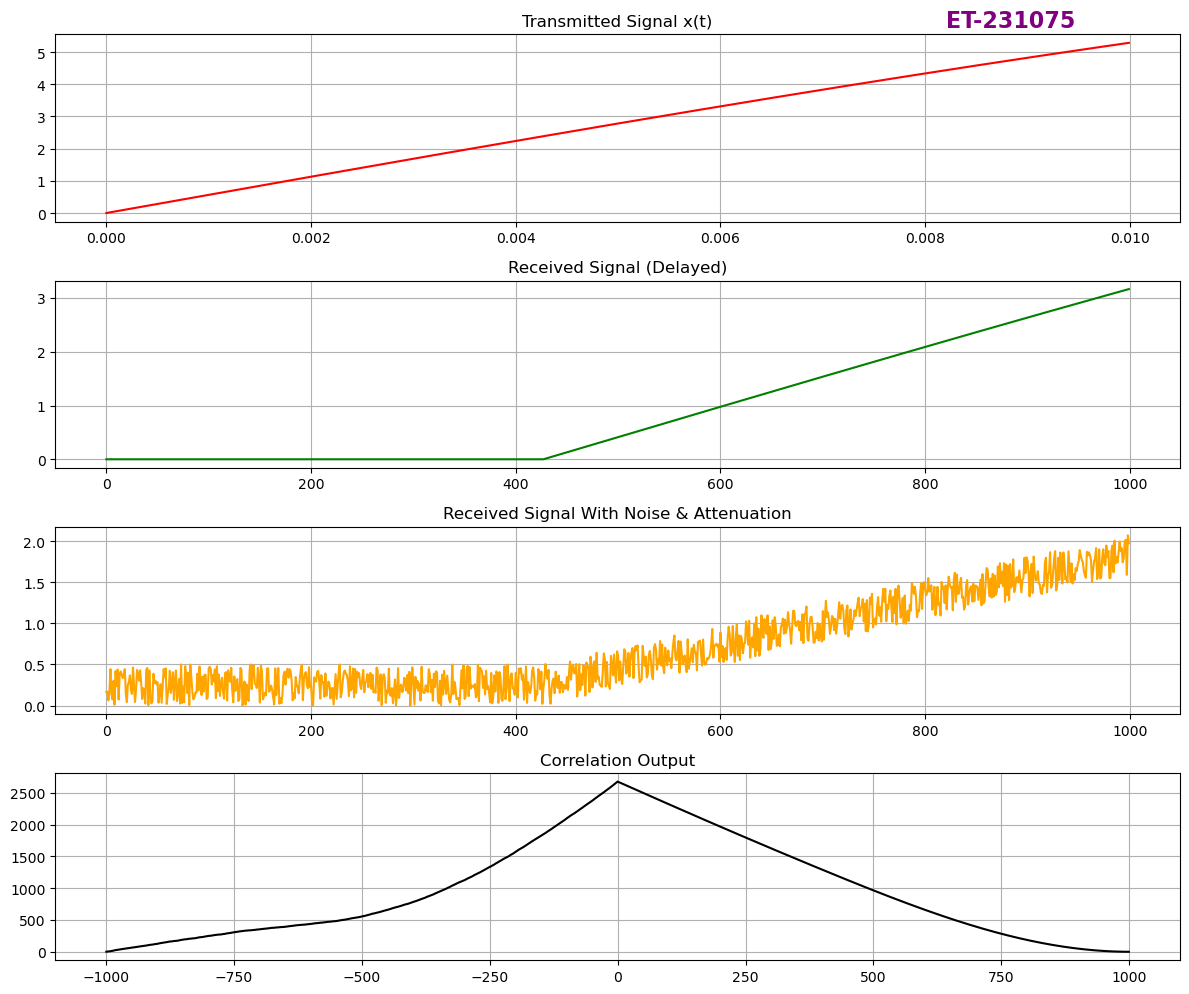

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

t = np.arange(0, 0.01, 0.01/1000)
sampling_time = 0.01/1000
A = 2
L = 3
M = 7
# transmitted signal frequency uses (M + L)
freq = 10
# Transmitted signal x(t)
# x(t) = (A + M) * sin(2*pi*(M + L)*t)
x = 9 * np.sin(2 * np.pi * 10 * t)

# Create received signal with delay
delay_position = random.randint(100, 600)    # random target distance
r = np.zeros(1000)
r[delay_position:delay_position + len(x)] = x[:1000 - delay_position]

# Add noise + attenuation
noise = 0.5 * np.random.rand(1000)
attenuation = 0.5
r_noisy = attenuation * r + noise

# Cross-correlation
YY = np.correlate(r_noisy, x, mode='full')
N = np.arange(-(len(x)-1), len(r_noisy))
peak_value = np.max(YY)
peak_index = np.argmax(YY)

# Convert correlation index to delay in samples
t_index = peak_index - (len(x) - 1)
# distance = (delay_samples * Ts * speed) / 2
if t_index > 0:
    distance = (340 * (t_index) * sampling_time) / 2
else:
    distance = None

# Print outputs
print("Random delay position:", delay_position)
print("Correlation peak value:", peak_value)
print("Correlation index (raw):", peak_index)
print("Estimated delay (samples):", t_index)
if distance is not None:
    print(f"Estimated distance: {distance:.4f} meters")
else:
    print("No object detected.")

plt.figure(figsize=(12, 10))
# ID preserved from the image
plt.figtext(0.90, 0.99, "ET-231075", ha="right", va="top", fontsize=16, color="Purple", fontweight='bold')

plt.subplot(4, 1, 1)
plt.plot(t, x, color='r')
plt.title("Transmitted Signal x(t)")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(r, color='g')
plt.title("Received Signal (Delayed)")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(r_noisy, color='orange')
plt.title("Received Signal With Noise & Attenuation")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(N, YY, color='k')
plt.title("Correlation Output")
plt.grid(True)

plt.tight_layout()
plt.show()